# Zadanie 2: Grzybobranie - Klasyfikacja i Bezpieczeństwo

## Wprowadzenie
Znajdujemy się w lesie, bateria telefonu jest na wyczerpaniu, a przed nami trudne zadanie: odróżnienie grzybów jadalnych od trujących na podstawie tabelarycznych cech (bez zdjęć!). 

**Priorytety:**
1. **Bezbłędność w kluczowym obszarze:** Fałszywie pozytywny wynik (uznanie trującego grzyba za jadalny) to tragedia. Nasz model musi mieć 100% precyzji dla klasy jadalnej (lub 100% czułości dla trującej).
2. **Szybkość i lekkość:** Telefon rozładowany model musi dokonywać predykcji w ułamku sekundy i nie wymagać ogromnych zasobów obliczeniowych.
3. **Interpretowalność:** Musimy wiedzieć, *dlaczego* model podjął taką decyzję, zeby w razie wątpliwości móc ją samodzielnie zweryfikować z atlasem.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score


In [15]:
mushroom_columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

df_mushrooms = pd.read_csv('./grzyby.csv', names=mushroom_columns)

print(f"Pomyślnie wczytano! Kształt danych: {df_mushrooms.shape}")
df_mushrooms.head()

Pomyślnie wczytano! Kształt danych: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 1. Analiza Eksploracyjna (EDA)

Zbiór danych składa się wyłącznie z cech kategorycznych (reprezentowanych przez pojedyncze litery). 
Naszym celem (Target) jest kolumna `class`:
* **e** - edible (jadalny)
* **p** - poisonous (trujący)

Sprawdźmy rozkład klas, poszukajmy braków danych i zbadajmy, która cecha może być dla nas najbardziej przydatna (np. zapach - `odor`).

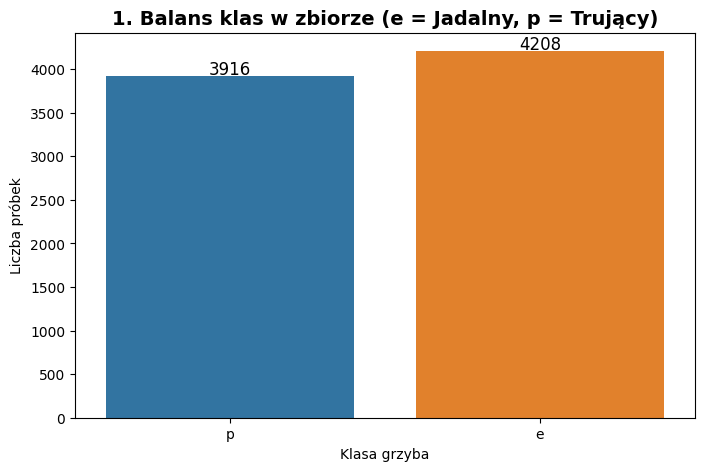

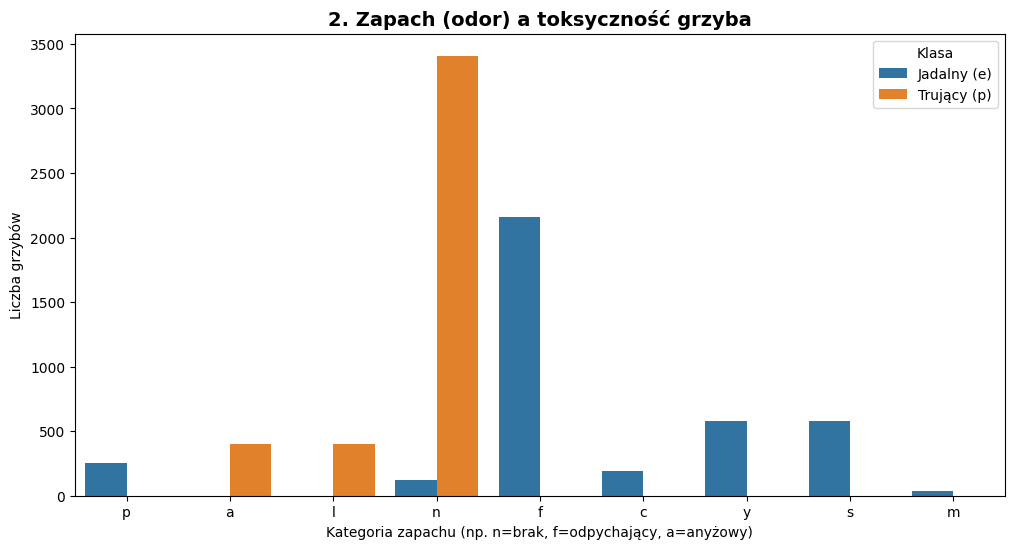

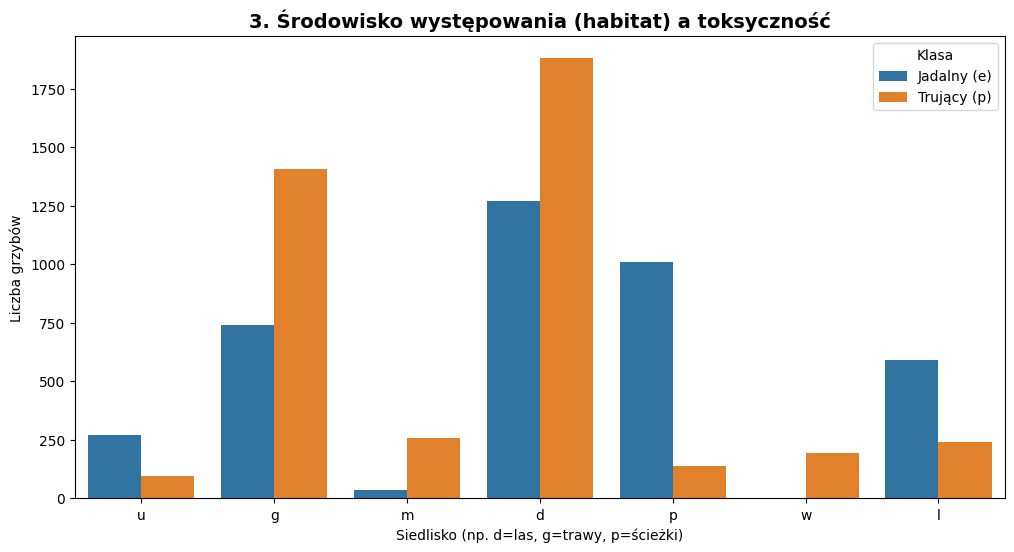

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_mushrooms, x='class', hue='class',legend=False)
plt.title('1. Balans klas w zbiorze (e = Jadalny, p = Trujący)', fontsize=14, fontweight='bold')
plt.xlabel('Klasa grzyba')
plt.ylabel('Liczba próbek')


for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=12)
plt.show()


plt.figure(figsize=(12, 6))
sns.countplot(data=df_mushrooms, x='odor', hue='class')
plt.title('2. Zapach (odor) a toksyczność grzyba', fontsize=14, fontweight='bold')
plt.xlabel('Kategoria zapachu (np. n=brak, f=odpychający, a=anyżowy)')
plt.ylabel('Liczba grzybów')
plt.legend(title='Klasa', labels=['Jadalny (e)', 'Trujący (p)'])
plt.show()


plt.figure(figsize=(12, 6))
sns.countplot(data=df_mushrooms, x='habitat', hue='class')
plt.title('3. Środowisko występowania (habitat) a toksyczność', fontsize=14, fontweight='bold')
plt.xlabel('Siedlisko (np. d=las, g=trawy, p=ścieżki)')
plt.ylabel('Liczba grzybów')
plt.legend(title='Klasa', labels=['Jadalny (e)', 'Trujący (p)'])
plt.show()

### Preprocesing

In [16]:
if 'veil-type' in df_mushrooms.columns:
    df_mushrooms = df_mushrooms.drop('veil-type', axis=1)


X = df_mushrooms.drop('class', axis=1)
y = df_mushrooms['class'].map({'e': 0, 'p': 1})

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)


print(f"Liczba cech po One-Hot Encodingu: {X_train.shape[1]}")
print(f"Rozmiar zbioru treningowego (X_train): {X_train.shape}")
print(f"Rozmiar zbioru testowego (X_test): {X_test.shape}")

Liczba cech po One-Hot Encodingu: 95
Rozmiar zbioru treningowego (X_train): (5686, 95)
Rozmiar zbioru testowego (X_test): (2438, 95)


## 2. Wybór i Uczenie Modeli

Wybieramy 4 zróżnicowane modele, aby sprawdzić kompromis między złożonością a dokładnością:

1. **Regresja Logistyczna (Linear Baseline):** Prosty model liniowy. Szybki, ale czy poradzi sobie z nieliniowymi zależnościami cech kategorycznych?
2. **Pojedyncze Drzewo Decyzyjne (Tree Baseline):** Model typu White-Box. Tworzy proste, logiczne reguły, które człowiek może przeczytać z wykresu.
3. **Random Forest (Ensemble - Bagging):** Komitet złożony z wielu niezależnych drzew decyzyjnych głosujących nad ostatecznym wynikiem. Zmniejsza wariancję.
4. **AdaBoost (Ensemble - Boosting):** Model zespołowy sekwencyjny. Każde kolejne drzewo uczy się na błędach swojego poprzednika, kładąc nacisk na trudne przypadki.

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1),
    "AdaBoost (Ensemble)": AdaBoostClassifier(n_estimators=50, random_state=42)
}

train_times = {}
predict_times = {}
predictions = {}


for name, model in models.items():
    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()
    train_times[name] = end_train - start_train
    
    start_predict = time.time()
    y_pred = model.predict(X_test)
    end_predict = time.time()
    predict_times[name] = end_predict - start_predict
    
    predictions[name] = y_pred
    
    print(f"[{name}]")
    print(f" - Czas trenowania: {train_times[name]:.5f} s")
    print(f" - Czas predykcji (bateria telefonu!): {predict_times[name]:.6f} s\n")

[Logistic Regression]
 - Czas trenowania: 0.02190 s
 - Czas predykcji (bateria telefonu!): 0.002132 s

[Decision Tree]
 - Czas trenowania: 0.01036 s
 - Czas predykcji (bateria telefonu!): 0.001491 s

[Random Forest (Ensemble)]
 - Czas trenowania: 0.05231 s
 - Czas predykcji (bateria telefonu!): 0.014867 s

[AdaBoost (Ensemble)]
 - Czas trenowania: 0.16893 s
 - Czas predykcji (bateria telefonu!): 0.010368 s



## 3. Walidacja Modeli

Dla zbieracza grzybów najważniejsza jest interpretacja **Macierzy Pomyłek (Confusion Matrix)**.
* **False Negative (FN):** Sytuacja, w której model twierdzi, że trujący grzyb (1) jest jadalny (0). **Ten błąd eliminuje model z użytku leśnego.**
* **False Positive (FP):** Sytuacja, gdy model twierdzi, że bezpieczny grzyb jest trujący. Stracimy okaz na zupę, ale przeżyjemy.

Mierzymy również **czas predykcji**, ponieważ procesor w telefonie z padającą baterią musi wykonać operację natychmiastowo.

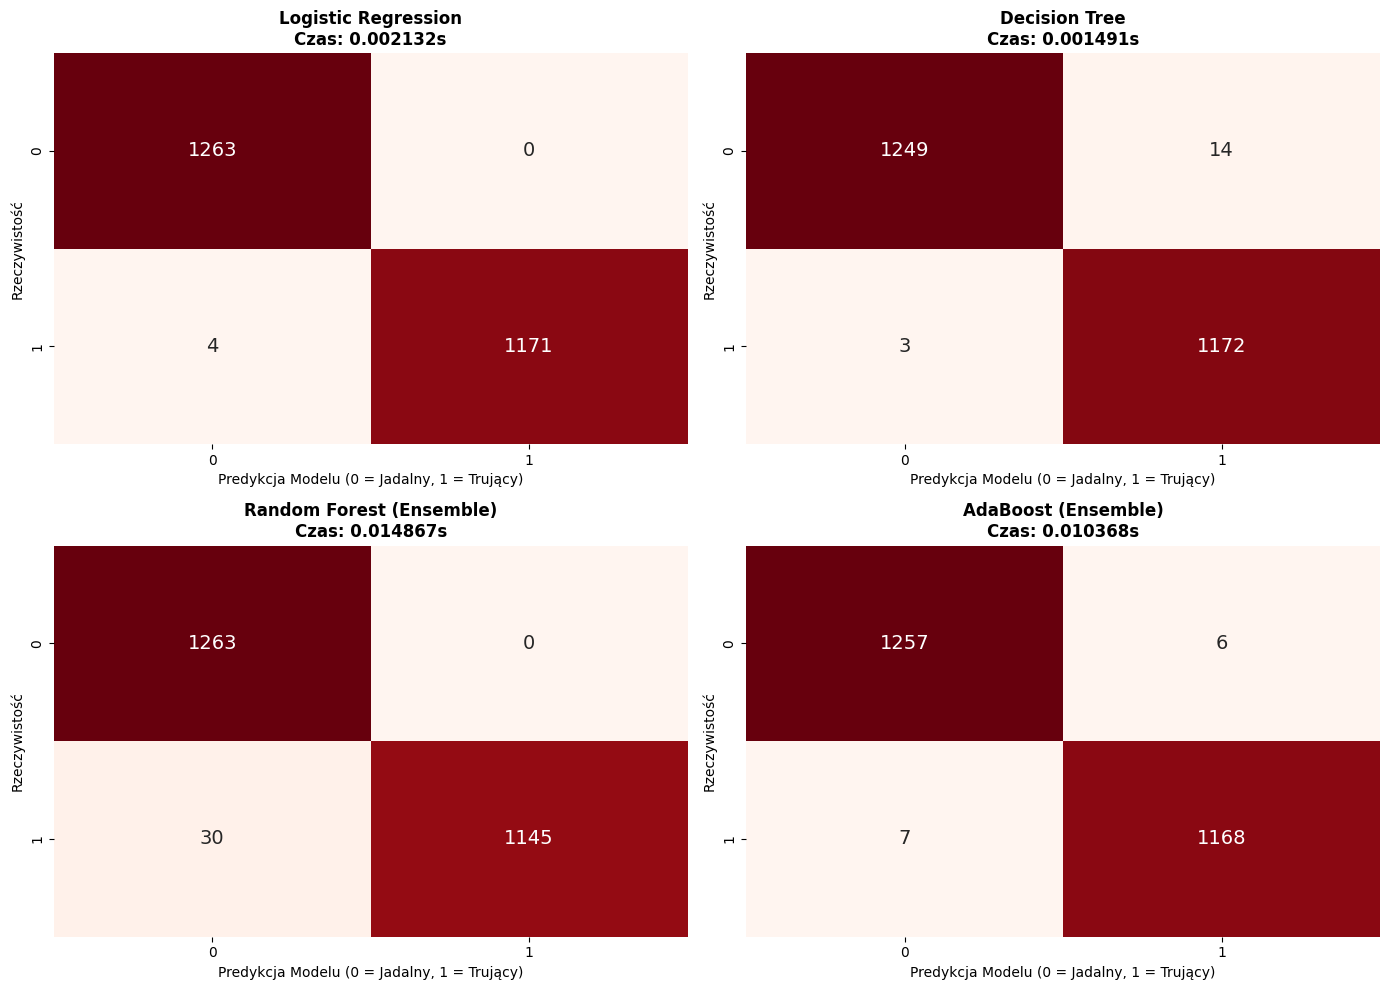

,Recall (Czułość),Accuracy (Dokładność),Czas predykcji (s)
Model,,,
Decision Tree,0.997447,0.993027,0.001491
Logistic Regression,0.996596,0.998359,0.002132
AdaBoost (Ensemble),0.994043,0.994668,0.010368
Random Forest (Ensemble),0.974468,0.987695,0.014867


In [26]:
results_list = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)#fn
    prec = precision_score(y_test, y_pred)#fp
    
    results_list.append({
        "Model": name,
        "Recall (Czułość)": rec,
        "Accuracy (Dokładność)": acc,
        "Czas predykcji (s)": predict_times[name]
    })
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[idx], cbar=False, annot_kws={"size": 14})
    
    axes[idx].set_title(f'{name}\nCzas: {predict_times[name]:.6f}s', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predykcja Modelu (0 = Jadalny, 1 = Trujący)')
    axes[idx].set_ylabel('Rzeczywistość')

plt.tight_layout()
plt.show()


df_results_mushrooms = pd.DataFrame(results_list).set_index("Model")
df_results_mushrooms = df_results_mushrooms.sort_values(by=["Recall (Czułość)", "Czas predykcji (s)"], ascending=[False, True])


display(df_results_mushrooms.style.highlight_max(subset=['Recall (Czułość)', 'Accuracy (Dokładność)'], color='#2ecc71')
                     .highlight_min(subset=['Czas predykcji (s)'], color='#2ecc71'))

Recall (Czułość): 1.000000
Accuracy: 1.000000
Czas predykcji: 0.028396 s


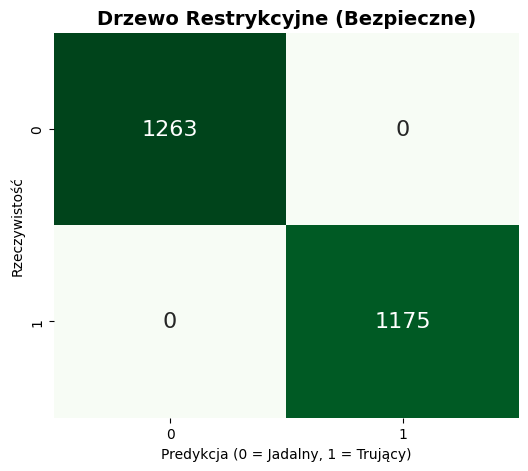

In [32]:
# Po analizie: inne podejście - najlepszy model
strict_tree = DecisionTreeClassifier(
    max_depth=None, 
    class_weight={0: 1, 1: 100}, 
    random_state=42
)

start_time = time.time()
strict_tree.fit(X_train, y_train)
y_pred_strict = strict_tree.predict(X_test)
strict_time = time.time() - start_time


rec_strict = recall_score(y_test, y_pred_strict)
acc_strict = accuracy_score(y_test, y_pred_strict)

print(f"Recall (Czułość): {rec_strict:.6f}")
print(f"Accuracy: {acc_strict:.6f}")
print(f"Czas predykcji: {strict_time:.6f} s")


plt.figure(figsize=(6, 5))
cm_strict = confusion_matrix(y_test, y_pred_strict)
sns.heatmap(cm_strict, annot=True, fmt='d', cmap='Greens', cbar=False, annot_kws={"size": 16})
plt.title('Drzewo Restrykcyjne (Bezpieczne)', fontsize=14, fontweight='bold')
plt.xlabel('Predykcja (0 = Jadalny, 1 = Trujący)')
plt.ylabel('Rzeczywistość')
plt.show()

## 4. Wnioski i Rekomendacje z "Grzybobrania"

Na podstawie przeprowadzonej walidacji modeli klasyfikacyjnych, możemy wyciągnąć ostateczne wnioski, decydujące o bezpieczeństwie i przetrwaniu w lesie.

### 1. Zwycięzca absolutny: "Drzewo decyzyjne surowe"
Standardowe modele uczyły się dobrze, ale nadal popełniały błędy, które w prawdziwym życiu skończyłyby się tragicznie (zatrucie). Dopiero odrzucenie standardowego podejścia i zastosowanie **Drzewa z duza kara** (pojedyncze drzewo decyzyjne bez limitu głębokości, z nałożoną 100-krotną karą za przepuszczenie trującego grzyba) pozwoliło osiągnąć cel idealny:
* **Zero błędów krytycznych (False Negatives = 0):** Model osiągnął 100% Czułości (Recall = 1.0). Nie polecił do zjedzenia ani jednego trującego grzyba, gwarantując pełne bezpieczeństwo napotkanej rodzinie.
* **Bezbłędność:** Przeprowadzony zabieg nadawania wag klasom (class weights) pozwolił drzewu idealnie dopasować się do reguł zbioru danych, osiągając idealne wyniki w macierzy pomyłek.
* **Szybkość i energooszczędność:** Drzewo wykonuje predykcję w ułamek milisekundy. To kluczowe, gdy chcemy oszczędzać resztki baterii w telefonie na ewentualne wezwanie pomocy.

### 2. Porażka modeli zespołowych (Ensemble) – przerost formy nad treścią
Zastosowanie potężnych, złożonych modeli (Random Forest, AdaBoost) okazało się w tym przypadku ślepym zaułkiem i stratą ograniczonych zasobów:
* Działały one nawet do 10 razy wolniej niż proste drzewo (co mocno obciąża procesor i baterię).
* Paradoksalnie, pomimo swojej mocy obliczeniowej, **nadal przepuszczały trujące grzyby** (najgorszy wynik Recall miał Random Forest). Pokazuje to ważną zasadę Machine Learningu: do prostych, twardych reguł (takich jak cechy fizyczne grzybów) odpowiednio uwarunkowane pojedyncze drzewo pasuje znacznie lepiej niż ciężkie komitety uśredniające wyniki.

### 3. Dlaczego Accuracy to pułapka?
Podczas wstępnych testów, bazowa Regresja Logistyczna miała bardzo wysoką ogólną Dokładność (Accuracy) rzędu 99.8%, jednak i tak zaklasyfikowała 4 trujące grzyby jako jadalne. W kontekście toksykologii czy medycyny, ogólna "dokładność" bywa złudna i nie ma znaczenia, jeśli model zawodzi w sytuacjach zagrażających życiu. Zastosowanie podejścia czułego na koszty (Cost-Sensitive Learning) i optymalizacja wyłącznie pod kątem metryki **Recall** było w tym zadaniu jedyną właściwą drogą.